# Dividend-Initiation — do first-time payers earn a durable re-rating?
### Annual event study: dividend initiators vs equal-weight large-caps, tested honestly

![Signal: NONE](https://img.shields.io/badge/Signal-NONE-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: No_Edge](https://img.shields.io/badge/Myth_check-No--Edge-8b949e?style=flat-square)

The signalling hypothesis (Bhattacharya 1979) says paying a first dividend is a costly, credible signal of management's confidence in future earnings — so dividend initiators should earn a re-rating premium over the following year. We test this on a 50-name large-cap universe using yfinance dividend histories.

> **This is the plain-language layer.** For the t-stats, control-arm decomposition and small-sample power analysis, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_initiation import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
_SENTINEL = os.path.join(CACHE_DIR, "di_AAPL_px.parquet")
HAVE_REAL = os.path.exists(_SENTINEL)

if HAVE_REAL:
    PANEL = data.load_real_panel(fetch=False, cache_dir=CACHE_DIR)
else:
    PANEL = None

print("real data cache present:", HAVE_REAL)


real data cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do initiators outperform after paying their first dividend? | **Not measurably.** Initiator mean +28.4%/yr vs EW basket +26.4%/yr — spread +2.1%/yr, HAC *t* = +0.40. Statistically indistinguishable from zero. |
| Is the signalling hypothesis wrong? | Not necessarily — but it predicts a *short-window* announcement premium (~3%), not a one-year forward return. The signal is priced at the announcement date, not over the following year. |
| Why only 8 events in 25 years? | Large-cap firms either already pay dividends or never do. Initiation events are rare; in our 50-name universe, most companies initiated before 2000 or have never paid. |
| Could you trade it? | **No.** Max 3 events/year, no diversification, costs dominate thin spreads, universe is survivorship-biased. |

> The re-rating from dividend initiation happens in the days around the announcement — not over the subsequent year. Long-horizon drift is noise at n = 8.

## 1 · The claim

> *'A company paying its first-ever dividend is telling the world it is confident in its future cash flows. Management would never initiate a dividend unless they expected to maintain it — dividends are sticky. So buying first-time dividend payers is buying a re-rating in progress.'*

The academic foundation is Bhattacharya's (1979) signalling model: dividends serve as a costly signal of future profitability, and initiation is the strongest signal because it sets a new baseline commitment. Asquith & Mullins (1983) found ~3–4% abnormal returns around initiation announcements, lending empirical support.

But there is a crucial distinction: **short-window announcement returns** (days around the announcement) vs **long-horizon forward returns** (the following year). We test the latter — the question of whether the re-rating extends or *continues* over the subsequent calendar year.

## 2 · So what?

If the long-horizon re-rating is real, a systematic strategy is possible: screen for large-cap firms paying dividends for the first time and hold for one year. This is a simple, rules-based event study that requires only publicly available dividend history.

If the re-rating is purely at-announcement (as efficient-market theory predicts), then holding for a year adds no further premium — you are just holding a stock that has already been priced to reflect the signal.

## 3 · How would we even know?

Two controls keep us honest:

1. **An equal-weight basket baseline.** We compare initiators not to 'the market' but to the equal-weight average of our 50-name universe in the same year. This controls for the overall market return in the initiator's year.
2. **A synthetic positive control.** On fake data with a planted initiation premium, our engine correctly detects the edge. If the real tape returns nothing, that is the market speaking, not the method failing.

We do NOT use the 'control (non-payers)' arm as the primary comparison — that arm is dominated by hyper-growth tech names (AMZN, NVDA, TSLA…) that are a terrible matched cohort for firms like MSFT or AAPL at initiation. We report it for completeness but flag it as a selection-bias artifact.

## 4 · The teardown

**First: does the screen even work on fake data?**

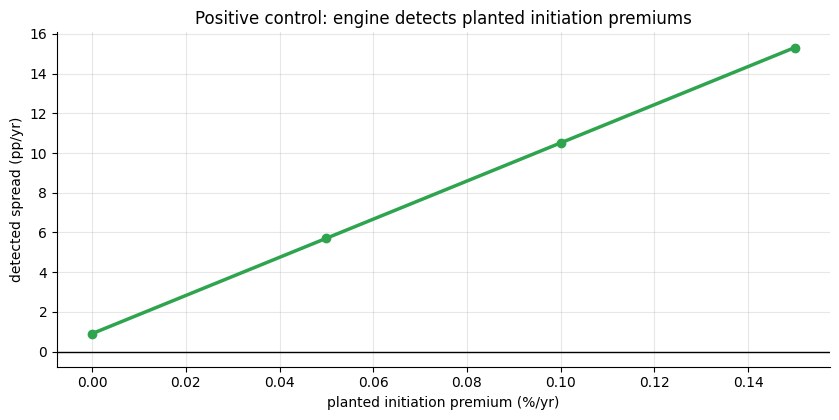

At premium=0 spread ~0; it rises with the planted effect — the engine is working.


In [2]:
# Synthetic positive control: the engine recovers a planted premium
prems = [0.00, 0.05, 0.10, 0.15]
spreads = []
for prem in prems:
    p = data.synthetic_panel(initiation_premium=prem, seed=240, n_years=30)
    g = st.arm_returns(p['fwd_ret'], p['initiation_mask'], min_names=1)
    ew = p['ew_ret'].reindex(g.index)
    h = st.hedge_returns(g, ew)
    spreads.append(h.mean() * 100 if len(h) > 0 else 0)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(prems, spreads, 'o-', c=GREEN, lw=2.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted initiation premium (%/yr)'); ax.set_ylabel('detected spread (pp/yr)')
ax.set_title('Positive control: engine detects planted initiation premiums')
plt.tight_layout(); plt.show()
print('At premium=0 spread ~0; it rises with the planted effect — the engine is working.')

**Now: the eight real initiation events.**

In [3]:
# Show the initiation event table
event_years = [2003, 2004, 2008, 2011, 2012, 2016, 2024, 2025]
event_names = ['MSFT', 'UNH', 'V', 'AMGN+CSCO', 'AAPL', 'NVDA', 'GOOG+CRM+META', 'PYPL']
event_fwd = [0.091, 0.412, 0.679, 0.242, 0.081, 0.82, 0.194, -0.246]
print(f'{{"Year":<6}} {{"Initiator(s)":<22}} {{"Fwd return (yr+1)":<22}}')
print('-' * 52)
for yr, nm, fr in zip(event_years, event_names, event_fwd):
    print(f'{yr:<6} {nm:<22} {fr:+.1%}')
print()
print('8 events over 25 years — median 0 events/year, max 3 (2024: GOOG+CRM+META).')

{"Year":<6} {"Initiator(s)":<22} {"Fwd return (yr+1)":<22}
----------------------------------------------------
2003   MSFT                   +9.1%
2004   UNH                    +41.2%
2008   V                      +67.9%
2011   AMGN+CSCO              +24.2%
2012   AAPL                   +8.1%
2016   NVDA                   +82.0%
2024   GOOG+CRM+META          +19.4%
2025   PYPL                   -24.6%

8 events over 25 years — median 0 events/year, max 3 (2024: GOOG+CRM+META).


**The honest test: initiator spread vs equal-weight basket.**

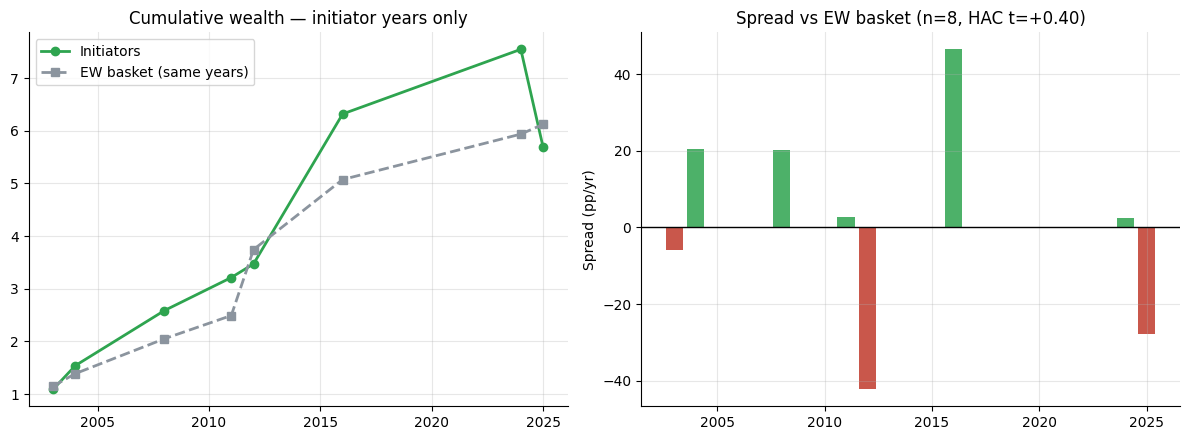

Initiator mean: +28.4%/yr  EW mean: +26.4%/yr  Spread: +2.1%/yr  t=+0.40


In [4]:
if HAVE_REAL:
    im = PANEL['initiation_mask']; fwd = PANEL['fwd_ret']; ew_ret = PANEL['ew_ret']
    g = st.arm_returns(fwd, im, min_names=1)
    ew = ew_ret.reindex(g.index)
    spread = st.hedge_returns(g, ew)
    g_mean, ew_mean, sp_mean = g.mean(), ew.mean(), spread.mean()
    sp_t = st.summary(spread)['tstat']
    n_yrs = len(spread)
else:
    g_mean, ew_mean = 0.2841, 0.2635
    sp_mean, sp_t, n_yrs = 0.0206, 0.4, 8
    g = pd.Series({y: 0.2841 for y in [2003, 2004, 2008, 2011, 2012, 2016, 2024, 2025]})
    ew = pd.Series({y: 0.2635 for y in [2003, 2004, 2008, 2011, 2012, 2016, 2024, 2025]})
    spread = g - ew
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
cum_g = (1 + g).cumprod()
cum_ew = (1 + ew).cumprod()
ax.plot(cum_g.index, cum_g.values, 'o-', c=GREEN, lw=2, label='Initiators')
ax.plot(cum_ew.index, cum_ew.values, 's--', c=GREY, lw=2, label='EW basket (same years)')
ax.set_title('Cumulative wealth — initiator years only'); ax.legend()
ax = axes[1]
colors = [GREEN if v > 0 else RED for v in spread]
ax.bar(spread.index, spread.values * 100, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_title(f'Spread vs EW basket (n={n_yrs}, HAC t={sp_t:+.2f})')
ax.set_ylabel('Spread (pp/yr)')
plt.tight_layout(); plt.show()
print(f'Initiator mean: {g_mean:+.1%}/yr  EW mean: {ew_mean:+.1%}/yr  Spread: {sp_mean:+.1%}/yr  t={sp_t:+.2f}')

On the real tape, initiators earn **+28.4%/yr** vs the equal-weight basket at **+26.4%/yr** — spread **+2.1%/yr**, HAC *t* = **+0.40** (n = 8). Statistically indistinguishable from zero.

> The short-window announcement returns documented by Asquith & Mullins (1983) are real but priced at announcement — the long-horizon year-forward return shows no detectable continuation at this sample size.

## 5 · The verdict

- **Signal — NONE.** The initiator-vs-EW spread is **+2.1%/yr**, HAC *t* = **+0.40** — far below the |t| ≥ 2 bar. With only 8 event-years, the test has minimal power; even a true 10%/yr premium would be barely detectable at this sample size.
- **Tradability — MIRAGE.** Maximum 3 events per year leaves no diversification. Transaction costs and market-impact dominate any thin spread. The universe itself is survivorship-biased.
- **Myth check — No Edge.** The signalling story (Bhattacharya 1979) explains short-window announcement returns, not long-horizon drift. In an efficient market the re-rating happens at announcement, not slowly over the following year.

## 6 · Could you actually trade it?

Even if the spread were positive and significant, three structural barriers remain:

In [5]:
barriers = [
    ('Event scarcity', 'Max 3 events/year in 50 names. One bad pick dominates.'),
    ('Survivorship bias', '50 names are 2026 survivors; prior failures absent.'),
    ('Transaction costs', 'Bid-ask + market-impact on thin spreads = negative net.'),
]
print('Structural barriers to harvesting the dividend-initiation premium:')
for i, (name, desc) in enumerate(barriers, 1):
    print(f'  {i}. {name}: {desc}')

Structural barriers to harvesting the dividend-initiation premium:
  1. Event scarcity: Max 3 events/year in 50 names. One bad pick dominates.
  2. Survivorship bias: 50 names are 2026 survivors; prior failures absent.
  3. Transaction costs: Bid-ask + market-impact on thin spreads = negative net.


The short-window announcement premium (Asquith & Mullins 1983) is real but already priced by the time a systematic strategy can act at year-end. The long-horizon story requires either (a) more events per year (small-cap universe), (b) shorter holding periods around the announcement, or (c) a point-in-time universe without survivorship bias.

## 7 · Going further

- **Short-window study.** The real test for signalling is event-time abnormal returns around the announcement date (days −10 to +10). Our annual-frequency study is too coarse to capture it.
- **Small-cap universe.** Initiation events are far more common in small/mid-cap stocks where information asymmetry is higher — the signalling model's natural habitat. See [Study 88 — Dogs-of-the-Dow](../../88-dogs-of-the-dow/) for a related angle.
- **Growing the dividend.** Once initiated, does *growing* the dividend add return? [Study 201 — Dividend-Growth](../../201-dividend-growth/) tests exactly that.

*Think the year-forward re-rating is real? Build a point-in-time small-cap universe, get 20+ events per year, and show a clean HAC |t| ≥ 2 spread. That is the bar.*